# 03h — Does the training-sample design drive the results?

The paper trains its random forest on equal numbers of regrowth and non-regrowth
points, with non-regrowth drawn at random over the whole domain. C. Cloud's
reanalysis of the paper in Brazil (2026, Matters Arising manuscript and code:
https://github.com/CannonCloud/tropical-regeneration-reanalysis) argues that both choices shape
the output: the 50/50 ratio inflates areas, and random non-regrowth lets the model
separate the classes by broad climate rather than by local site conditions. This
notebook repeats his two tests in Colombia, with the step-2 specification
unchanged except for how the training sample is drawn.

- **A — Training prevalence.** Same total sample size (39,523), regrowth share
  50 %, 20 %, 5 % and the landscape prevalence π. Each model is scored on the
  step-2 validation set and its area is computed uncalibrated and after the
  prior-shift correction (Saerens et al. 2002) to π.
- **B — Paired non-regrowth.** Cloud's "paired" design: 80 % of non-regrowth
  training points are drawn within 3 km of regrowth, 20 % at random. Compared
  with the step-2 (global) design on (i) the random validation set, (ii) a
  *local* validation set whose non-regrowth points also lie within 3 km of
  regrowth, (iii) grouped permutation importance (climate vs local predictors),
  (iv) calibrated areas and the top-5 % priority pixels.
- **C — Forward test.** The same two designs on MapBiomas labels: trained on
  2000→2012 regrowth, scored on 2012→2024 regrowth (as in `03f`, E2).

**Distance to regrowth** is measured to the nearest regrowth point of the 1-in-100
systematic grid of `02b` (300 m spacing): Fagan regrowth for A–B, MapBiomas
2000→2012 regrowth for C. This is an extension; the paper uses only the global
50/50 design.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from healpix_geo.nested import lonlat_to_healpix, vertices
from matplotlib.collections import PolyCollection
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.neighbors import BallTree

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
SMOKE = os.environ.get("SMOKE", "0") == "1"
CLEAN = Path("../data/clean_smoke" if SMOKE else "../data/clean")
RESULTS = Path("../results/smoke" if SMOKE else "../results")
FIGURES = Path("../figures/smoke" if SMOKE else "../figures")
for d in (RESULTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)
N_TREES = 100 if SMOKE else 500
SEED = 20261003
MHA = 1e10
GRID_W = 100
R_EARTH_KM = 6371.0088
ANNULUS_KM = 3.0  # Cloud's annulus: non-regrowth within 3 km of regrowth
PAIRED_SHARE = 0.8  # share of non-regrowth training points from the annulus
TOP_SHARE = 0.05  # priority pixels: top 5 % of the prediction domain
HP_DEPTH = 8
FINAL_VARS = ["forest_density_2000", "dist_forest_2000", "ocdens", "phihox", "pc1", "pc2", "pc3", "pc4", "lc_2000", "biome"]
CLIMATE_VARS = ["pc1", "pc2", "pc3", "pc4", "biome"]
PRED_MAP = {"forest_density_2000": "forest_density_2018", "dist_forest_2000": "dist_forest_2018", "lc_2000": "lc_2015"}
VARS_2018 = [PRED_MAP.get(v, v) for v in FINAL_VARS]
VARS_FW = [v.replace("2000", "2012") for v in FINAL_VARS]
COL_SHARE = 188_921 / 4_780_000
N_TRAIN = 2_000 if SMOKE else int(round(1_000_000 * COL_SHARE))
N_PERM = 4_000 if SMOKE else 20_000
POOL_SHARE = 6 / 10.87  # MapBiomas grid split, as in 03f

samples = pd.read_parquet(CLEAN / "samples.parquet")
grid = pd.read_parquet(CLEAN / "pred_grid.parquet", columns=["lon", "lat", "grow", "gcol", "area_ell", "label",
                                                             "is_pred_domain", *dict.fromkeys(FINAL_VARS + VARS_2018)])
mbg = pd.read_parquet(CLEAN / "mapbiomas_grid.parquet", columns=["grow", "gcol", "forest_density_2012",
                                                                  "dist_forest_2012", "lc_2012", "mb_label_fw1",
                                                                  "mb_label_fw2"])
assert (grid.grow.to_numpy() == mbg.grow.to_numpy()).all() and (grid.gcol.to_numpy() == mbg.gcol.to_numpy()).all()
grid = pd.concat([grid, mbg.drop(columns=["grow", "gcol"])], axis=1)
del mbg
grid["a"] = grid.area_ell * GRID_W
sums = pd.read_csv(CLEAN / "tile_sums.csv").drop(columns="tile").sum()
PI = float(sums["class1_area_ell"] / (sums["class1_area_ell"] + sums["class0_area_ell"]))
pool = samples[samples.set == "train_pool"]
val = samples[samples.set == "validation"].reset_index(drop=True)
print(f"pool {len(pool):,}; validation {len(val):,}; grid {len(grid):,}; prevalence pi = {PI:.5f}")


def make_rf(seed: int = SEED) -> RandomForestClassifier:
    """Identical to 03_analysis.make_rf (R randomForest classification defaults)."""
    return RandomForestClassifier(n_estimators=N_TREES, max_features=3, min_samples_leaf=1, bootstrap=True,
                                  oob_score=True, n_jobs=-1, random_state=seed)


def prior_shift(p: np.ndarray, pi: float, train_prev: float = 0.5) -> np.ndarray:
    num = p * pi / train_prev
    return num / (num + (1 - p) * (1 - pi) / (1 - train_prev))


def scores(y: np.ndarray, p: np.ndarray) -> dict[str, float]:
    return {"accuracy": float(((p > 0.5) == y).mean()), "balanced_accuracy": float(balanced_accuracy_score(y, p > 0.5)),
            "sensitivity": float((p[y == 1] > 0.5).mean()), "specificity": float((p[y == 0] <= 0.5).mean()),
            "auc": float(roc_auc_score(y, p)), "n": int(len(y)), "n_regrowth": int((y == 1).sum())}


def km_to_nearest(ref: pd.DataFrame, pts: pd.DataFrame) -> np.ndarray:
    tree = BallTree(np.radians(ref[["lat", "lon"]].to_numpy()), metric="haversine")
    d, _ = tree.query(np.radians(pts[["lat", "lon"]].to_numpy()), k=1)
    return d[:, 0] * R_EARTH_KM


def draw(df: pd.DataFrame, label: str, n1: int, n0: int, near: np.ndarray | None = None,
         seed: int = SEED) -> pd.DataFrame:
    """n1 regrowth + n0 non-regrowth; with `near`, PAIRED_SHARE of non-regrowth come from the annulus."""
    c1 = df[df[label] == 1]
    c1 = c1.sample(n=min(n1, len(c1)), random_state=seed)
    c0 = df[df[label] == 0]
    n0 = min(n0, len(c0))  # binds only in smoke mode
    if near is None:
        return pd.concat([c1, c0.sample(n=n0, random_state=seed)])
    annulus = c0[near[(df[label] == 0).to_numpy()]]
    n_near = min(int(round(PAIRED_SHARE * n0)), len(annulus))
    a = annulus.sample(n=n_near, random_state=seed)
    b = c0.drop(index=a.index).sample(n=n0 - n_near, random_state=seed)
    return pd.concat([c1, a, b])


def local_set(df: pd.DataFrame, label: str, near: np.ndarray, seed: int = SEED) -> pd.DataFrame:
    """All regrowth + an equal number of non-regrowth points from the annulus."""
    c1 = df[df[label] == 1]
    c0 = df[(df[label] == 0).to_numpy() & near]
    return pd.concat([c1, c0.sample(n=min(len(c1), len(c0)), random_state=seed)])


rows: list[dict] = []


def add(part: str, design: str, metric: str, value: float, n: int | None = None, note: str = "") -> None:
    rows.append(dict(part=part, design=design, metric=metric, value=value, n=n, note=note))


g = grid[grid.is_pred_domain].dropna(subset=VARS_2018).copy()
Xg = g[VARS_2018].to_numpy()
print(f"prediction-domain grid points with complete 2018 predictors: {len(g):,}")


def grid_area(p: np.ndarray) -> float:
    return float((p * g.a.to_numpy()).sum() / MHA)

pool 151,980; validation 123,356; grid 12,161,726; prevalence pi = 0.01644


prediction-domain grid points with complete 2018 predictors: 2,456,636


## A — Training prevalence

Total size fixed at the step-2 value; only the regrowth share changes. The 50 %
row is the step-2 draw and must reproduce its validation accuracy (0.8867) and
uncalibrated area (3.989 Mha).

In [3]:
for r in [0.5, 0.2, 0.05, PI]:
    n1 = int(round(r * N_TRAIN))
    tr = (pd.concat([grp.sample(n=min(N_TRAIN // 2, len(grp)), random_state=SEED) for _, grp in pool.groupby("label")]) if r == 0.5
          else draw(pool, "label", n1, N_TRAIN - n1))
    m = make_rf().fit(tr[FINAL_VARS].to_numpy(), tr.label.to_numpy())
    pv = m.predict_proba(val[FINAL_VARS].to_numpy())[:, 1]
    pg = m.predict_proba(Xg)[:, 1]
    design = f"regrowth_share_{r:.4f}"
    for k, v in scores(val.label.to_numpy(), pv).items():
        add("A_prevalence", design, k, v, len(val), "step-2 validation set (balanced, random)")
    add("A_prevalence", design, "training_regrowth_share", r, len(tr))
    add("A_prevalence", design, "expected_area_uncalibrated_mha", grid_area(pg), len(g), "sum p x area, as in the paper")
    add("A_prevalence", design, "expected_area_prior_shift_mha", grid_area(prior_shift(pg, PI, r)), len(g),
        "Saerens prior shift from the training share to pi")
    add("A_prevalence", design, "area_p_gt05_mha", grid_area((pg > 0.5).astype(float)), len(g))
    print(design, {k: round(v, 4) for k, v in scores(val.label.to_numpy(), pv).items()},
          f"area uncal {grid_area(pg):.3f}, prior-shift {grid_area(prior_shift(pg, PI, r)):.3f} Mha")
prev = pd.DataFrame([x for x in rows if x["part"] == "A_prevalence"])

regrowth_share_0.5000 {'accuracy': 0.8867, 'balanced_accuracy': 0.8867, 'sensitivity': 0.853, 'specificity': 0.9204, 'auc': 0.9513, 'n': 123356, 'n_regrowth': 61678} area uncal 3.989, prior-shift 0.188 Mha


regrowth_share_0.2000 {'accuracy': 0.8514, 'balanced_accuracy': 0.8514, 'sensitivity': 0.7206, 'specificity': 0.9822, 'auc': 0.9443, 'n': 123356, 'n_regrowth': 61678} area uncal 1.770, prior-shift 0.202 Mha


regrowth_share_0.0500 {'accuracy': 0.7871, 'balanced_accuracy': 0.7871, 'sensitivity': 0.5775, 'specificity': 0.9967, 'auc': 0.9306, 'n': 123356, 'n_regrowth': 61678} area uncal 0.593, prior-shift 0.224 Mha


regrowth_share_0.0164 {'accuracy': 0.7374, 'balanced_accuracy': 0.7374, 'sensitivity': 0.4752, 'specificity': 0.9997, 'auc': 0.9161, 'n': 123356, 'n_regrowth': 61678} area uncal 0.240, prior-shift 0.240 Mha


## B — Paired non-regrowth (Fagan labels)

In [4]:
ref_fagan = grid[grid.label == 1]
pool = pool.assign(km=km_to_nearest(ref_fagan, pool))
val = val.assign(km=km_to_nearest(ref_fagan, val))
near_pool, near_val = (pool.km <= ANNULUS_KM).to_numpy(), (val.km <= ANNULUS_KM).to_numpy()
for nm, df, near in [("pool", pool, near_pool), ("validation", val, near_val)]:
    c0 = (df.label == 0).to_numpy()
    add("B_paired", "data", f"{nm}_nonregrowth_share_within_{ANNULUS_KM:g}km", float(near[c0].mean()), int(c0.sum()))
    add("B_paired", "data", f"{nm}_nonregrowth_median_km_to_regrowth", float(np.median(df.km[c0])), int(c0.sum()))
    add("B_paired", "data", f"{nm}_regrowth_median_km_to_regrowth_grid", float(np.median(df.km[~c0])), int((~c0).sum()),
        "regrowth sample points to the nearest regrowth grid point (lattice resolution check)")
print(pd.DataFrame(rows[-6:])[["metric", "value", "n"]].to_string(index=False))

train_b = {"global": pd.concat([grp.sample(n=min(N_TRAIN // 2, len(grp)), random_state=SEED) for _, grp in pool.groupby("label")]),
           "paired": draw(pool, "label", N_TRAIN // 2, N_TRAIN - N_TRAIN // 2, near_pool)}
loc_val = local_set(val, "label", near_val)
models, p_val, p_grid = {}, {}, {}
for design, tr in train_b.items():
    m = make_rf().fit(tr[FINAL_VARS].to_numpy(), tr.label.to_numpy())
    models[design] = m
    p_val[design] = m.predict_proba(val[FINAL_VARS].to_numpy())[:, 1]
    p_loc = m.predict_proba(loc_val[FINAL_VARS].to_numpy())[:, 1]
    for k, v in scores(val.label.to_numpy(), p_val[design]).items():
        add("B_paired", design, f"random_validation_{k}", v, len(val), "step-2 validation set")
    for k, v in scores(loc_val.label.to_numpy(), p_loc).items():
        add("B_paired", design, f"local_validation_{k}", v, len(loc_val),
            f"validation regrowth + equal non-regrowth within {ANNULUS_KM:g} km of regrowth")
    add("B_paired", design, "training_nonregrowth_median_km", float(np.median(tr.km[tr.label == 0])),
        int((tr.label == 0).sum()))
    p_grid[design] = m.predict_proba(Xg)[:, 1]
    print(design, "random", {k: round(v, 4) for k, v in scores(val.label.to_numpy(), p_val[design]).items()})
    print(design, "local ", {k: round(v, 4) for k, v in scores(loc_val.label.to_numpy(), p_loc).items()})

                                        metric    value     n
             pool_nonregrowth_share_within_3km 0.353560 75990
        pool_nonregrowth_median_km_to_regrowth 4.316927 75990
      pool_regrowth_median_km_to_regrowth_grid 0.339077 75990
       validation_nonregrowth_share_within_3km 0.355070 61678
  validation_nonregrowth_median_km_to_regrowth 4.292252 61678
validation_regrowth_median_km_to_regrowth_grid 0.348222 61678


global random {'accuracy': 0.8867, 'balanced_accuracy': 0.8867, 'sensitivity': 0.853, 'specificity': 0.9204, 'auc': 0.9513, 'n': 123356, 'n_regrowth': 61678}
global local  {'accuracy': 0.8501, 'balanced_accuracy': 0.8474, 'sensitivity': 0.853, 'specificity': 0.8417, 'auc': 0.9245, 'n': 83578, 'n_regrowth': 61678}


paired random {'accuracy': 0.8791, 'balanced_accuracy': 0.8791, 'sensitivity': 0.8186, 'specificity': 0.9395, 'auc': 0.9434, 'n': 123356, 'n_regrowth': 61678}
paired local  {'accuracy': 0.841, 'balanced_accuracy': 0.8614, 'sensitivity': 0.8186, 'specificity': 0.9042, 'auc': 0.9298, 'n': 83578, 'n_regrowth': 61678}


### Which predictors carry the signal?

Permutation importance (drop in AUC) on a balanced random subset of the validation
set, grouped into climate (bioclim PCs, biome) and local predictors (forest density
and distance, soil, land cover).

In [5]:
sub = pd.concat([grp.sample(n=min(N_PERM // 2, len(grp)), random_state=SEED) for _, grp in val.groupby("label")])
imp_rows = []
for design, m in models.items():
    pi_ = permutation_importance(m, sub[FINAL_VARS].to_numpy(), sub.label.to_numpy(), scoring="roc_auc", n_repeats=3,
                                 random_state=SEED, n_jobs=-1)
    s = pd.Series(np.clip(pi_.importances_mean, 0, None), index=FINAL_VARS)
    for v in FINAL_VARS:
        imp_rows.append(dict(design=design, variable=v, group="climate" if v in CLIMATE_VARS else "local",
                             auc_drop=float(pi_.importances_mean[FINAL_VARS.index(v)]), share=float(s[v] / s.sum())))
    add("B_paired", design, "importance_share_climate", float(s[CLIMATE_VARS].sum() / s.sum()), len(sub),
        "permutation importance (AUC drop, negatives clipped to 0)")
imp = pd.DataFrame(imp_rows)
imp.to_csv(RESULTS / "step3_sampling_importance.csv", index=False)
print(imp.pivot_table(index="variable", columns="design", values="share").round(3).to_string())

design               global  paired
variable                           
biome                 0.006   0.005
dist_forest_2000      0.570   0.578
forest_density_2000   0.143   0.168
lc_2000               0.016   0.012
ocdens                0.057   0.032
pc1                   0.034   0.030
pc2                   0.029   0.023
pc3                   0.036   0.035
pc4                   0.042   0.035
phihox                0.067   0.082


### Areas and priority pixels

The prior shift assumes that only the class ratio differs between training and
landscape. Paired sampling also changes *which* non-regrowth points are seen, so
the prior shift is mis-specified for it (Cloud's covariate-shift point). As a
design-neutral alternative, each model is calibrated empirically with isotonic
regression on the random validation set weighted to prevalence π (as in `03`).

In [6]:
y_val = val.label.to_numpy()
w_val = np.where(y_val == 1, PI, 1 - PI) / np.where(y_val == 1, (y_val == 1).mean(), (y_val == 0).mean())
p_cal = {}
for design in models:
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(p_val[design], y_val, sample_weight=w_val)
    p_cal[design] = iso.predict(p_grid[design])
    add("B_paired", design, "expected_area_uncalibrated_mha", grid_area(p_grid[design]), len(g))
    add("B_paired", design, "expected_area_prior_shift_mha", grid_area(prior_shift(p_grid[design], PI)), len(g),
        "Saerens prior shift; mis-specified for the paired design")
    add("B_paired", design, "expected_area_isotonic_mha", grid_area(p_cal[design]), len(g),
        "isotonic calibration on the random validation set, weighted to pi")
    add("B_paired", design, "area_p_gt05_uncalibrated_mha", grid_area((p_grid[design] > 0.5).astype(float)), len(g))

n_top = int(round(TOP_SHARE * len(g)))
top = {d: set(np.argsort(-p_grid[d], kind="stable")[:n_top]) for d in models}
add("B_paired", "global_vs_paired", "top5pct_overlap", len(top["global"] & top["paired"]) / n_top, n_top,
    "share of the global design's top-5 % grid points also in the paired design's top 5 %")
add("B_paired", "global_vs_paired", "spearman_p", float(stats.spearmanr(p_grid["global"], p_grid["paired"])[0]), len(g))
for design in models:
    idx = np.fromiter(top[design], dtype=int)
    for b, share in g.biome.iloc[idx].value_counts(normalize=True).items():
        add("B_paired", design, f"top5pct_share_biome_{int(b)}", float(share), n_top)
print(pd.DataFrame([x for x in rows if x["part"] == "B_paired" and "area" in x["metric"] or "top5" in x["metric"]
                    or "spearman" in x["metric"]])[["design", "metric", "value"]].to_string(index=False))

          design                         metric    value
          global expected_area_uncalibrated_mha 3.988743
          global  expected_area_prior_shift_mha 0.188251
          global     expected_area_isotonic_mha 0.207793
          global   area_p_gt05_uncalibrated_mha 2.025899
          paired expected_area_uncalibrated_mha 4.066441
          paired  expected_area_prior_shift_mha 0.154671
          paired     expected_area_isotonic_mha 0.207502
          paired   area_p_gt05_uncalibrated_mha 1.658765
global_vs_paired                top5pct_overlap 0.740760
global_vs_paired                     spearman_p 0.885474
          global          top5pct_share_biome_1 0.804049
          global          top5pct_share_biome_2 0.195951
          paired          top5pct_share_biome_1 0.882946
          paired          top5pct_share_biome_2 0.117054


## C — Forward test on MapBiomas labels

As `03f` E2: train on 2000→2012 regrowth with 2000 predictors, predict
2012→2024 regrowth with 2012 predictors. The global row must reproduce `03f`
(balanced accuracy 0.7171, AUC 0.7995). Precision at the top *k* % is the share of
the highest-ranked labelled points that did regrow in 2012–2024, the quantity that
matters for targeting. Calibration uses only period-1 information (prevalence π₁;
isotonic fit on period-1 validation points).

In [7]:
L1, L2 = "mb_label_fw1", "mb_label_fw2"
rng = np.random.default_rng(SEED)
grid["mb_set"] = np.where(rng.random(len(grid)) < POOL_SHARE, "train_pool", "validation")
l1 = grid[grid[L1] >= 0].dropna(subset=FINAL_VARS)
PI1 = float(grid.a[grid[L1] == 1].sum() / grid.a[grid[L1] >= 0].sum())
l1 = l1.assign(km=km_to_nearest(grid[grid[L1] == 1], l1))
tp1, vp1 = l1[l1.mb_set == "train_pool"], l1[l1.mb_set == "validation"]
near1 = (tp1.km <= ANNULUS_KM).to_numpy()
# a regrowth grid point is its own nearest regrowth point: distances of non-regrowth points only are meaningful
add("C_forward", "data", f"pool_nonregrowth_share_within_{ANNULUS_KM:g}km", float(near1[(tp1[L1] == 0).to_numpy()].mean()),
    int((tp1[L1] == 0).sum()))
train_c = {"global": pd.concat([grp.sample(n=min(N_TRAIN // 2, len(grp)), random_state=SEED)
                                for _, grp in tp1.groupby(L1)]),
           "paired": draw(tp1, L1, N_TRAIN // 2, N_TRAIN - N_TRAIN // 2, near1)}
l2 = grid[grid[L2] >= 0].dropna(subset=VARS_FW)
y2, w2 = l2[L2].to_numpy(), l2.a.to_numpy()
n1v = int((vp1[L1] == 1).sum())
v1 = pd.concat([vp1[vp1[L1] == 1], vp1[vp1[L1] == 0].sample(n=min(n1v, int((vp1[L1] == 0).sum())), random_state=SEED)])
y1v = v1[L1].to_numpy()
w1v = np.where(y1v == 1, PI1, 1 - PI1) / np.where(y1v == 1, (y1v == 1).mean(), (y1v == 0).mean())
p_fw = {}
for design, tr in train_c.items():
    m = make_rf().fit(tr[FINAL_VARS].to_numpy(), tr[L1].to_numpy())
    p2 = m.predict_proba(l2[VARS_FW].to_numpy())[:, 1]
    p_fw[design] = p2
    for k, v in scores(y2, p2).items():
        add("C_forward", design, f"forward_{k}", v, len(y2), "all MapBiomas-labelled 2012-2024 grid points, 2012 inputs")
    order = np.argsort(-p2, kind="stable")
    for k in (0.01, 0.05, 0.10):
        add("C_forward", design, f"forward_precision_top{int(k * 100)}pct", float(y2[order[:int(k * len(y2))]].mean()),
            int(k * len(y2)), "share of the top-ranked points that regrew in 2012-2024")
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(
        m.predict_proba(v1[FINAL_VARS].to_numpy())[:, 1], y1v, sample_weight=w1v)
    for nm, s in {"uncalibrated": p2, "prior_shift_pi1": prior_shift(p2, PI1), "isotonic_period1": iso.predict(p2)}.items():
        add("C_forward", design, f"predicted_regrowth_area_{nm}_mha", float((s * w2).sum() / MHA), len(y2))
    print(design, {k: round(v, 4) for k, v in scores(y2, p2).items()})
add("C_forward", "observed", "observed_regrowth_area_mha", float((y2 * w2).sum() / MHA), len(y2))
add("C_forward", "observed", "prevalence_2012_2024", float((y2 * w2).sum() / w2.sum()), len(y2),
    "precision of a random ranking")

res = pd.DataFrame(rows)
res.to_csv(RESULTS / "step3_sampling_design.csv", index=False)
print(res[res.part != "A_prevalence"].to_string(index=False, float_format=lambda v: f"{v:.4f}"))

global {'accuracy': 0.7385, 'balanced_accuracy': 0.7171, 'sensitivity': 0.6939, 'specificity': 0.7403, 'auc': 0.7995, 'n': 3255476, 'n_regrowth': 130997}


paired {'accuracy': 0.7467, 'balanced_accuracy': 0.7099, 'sensitivity': 0.6699, 'specificity': 0.75, 'auc': 0.7942, 'n': 3255476, 'n_regrowth': 130997}
     part           design                                         metric        value       n                                                                                 note
 B_paired             data              pool_nonregrowth_share_within_3km       0.3536   75990                                                                                     
 B_paired             data         pool_nonregrowth_median_km_to_regrowth       4.3169   75990                                                                                     
 B_paired             data       pool_regrowth_median_km_to_regrowth_grid       0.3391   75990 regrowth sample points to the nearest regrowth grid point (lattice resolution check)
 B_paired             data        validation_nonregrowth_share_within_3km       0.3551   61678                                  

## Figure

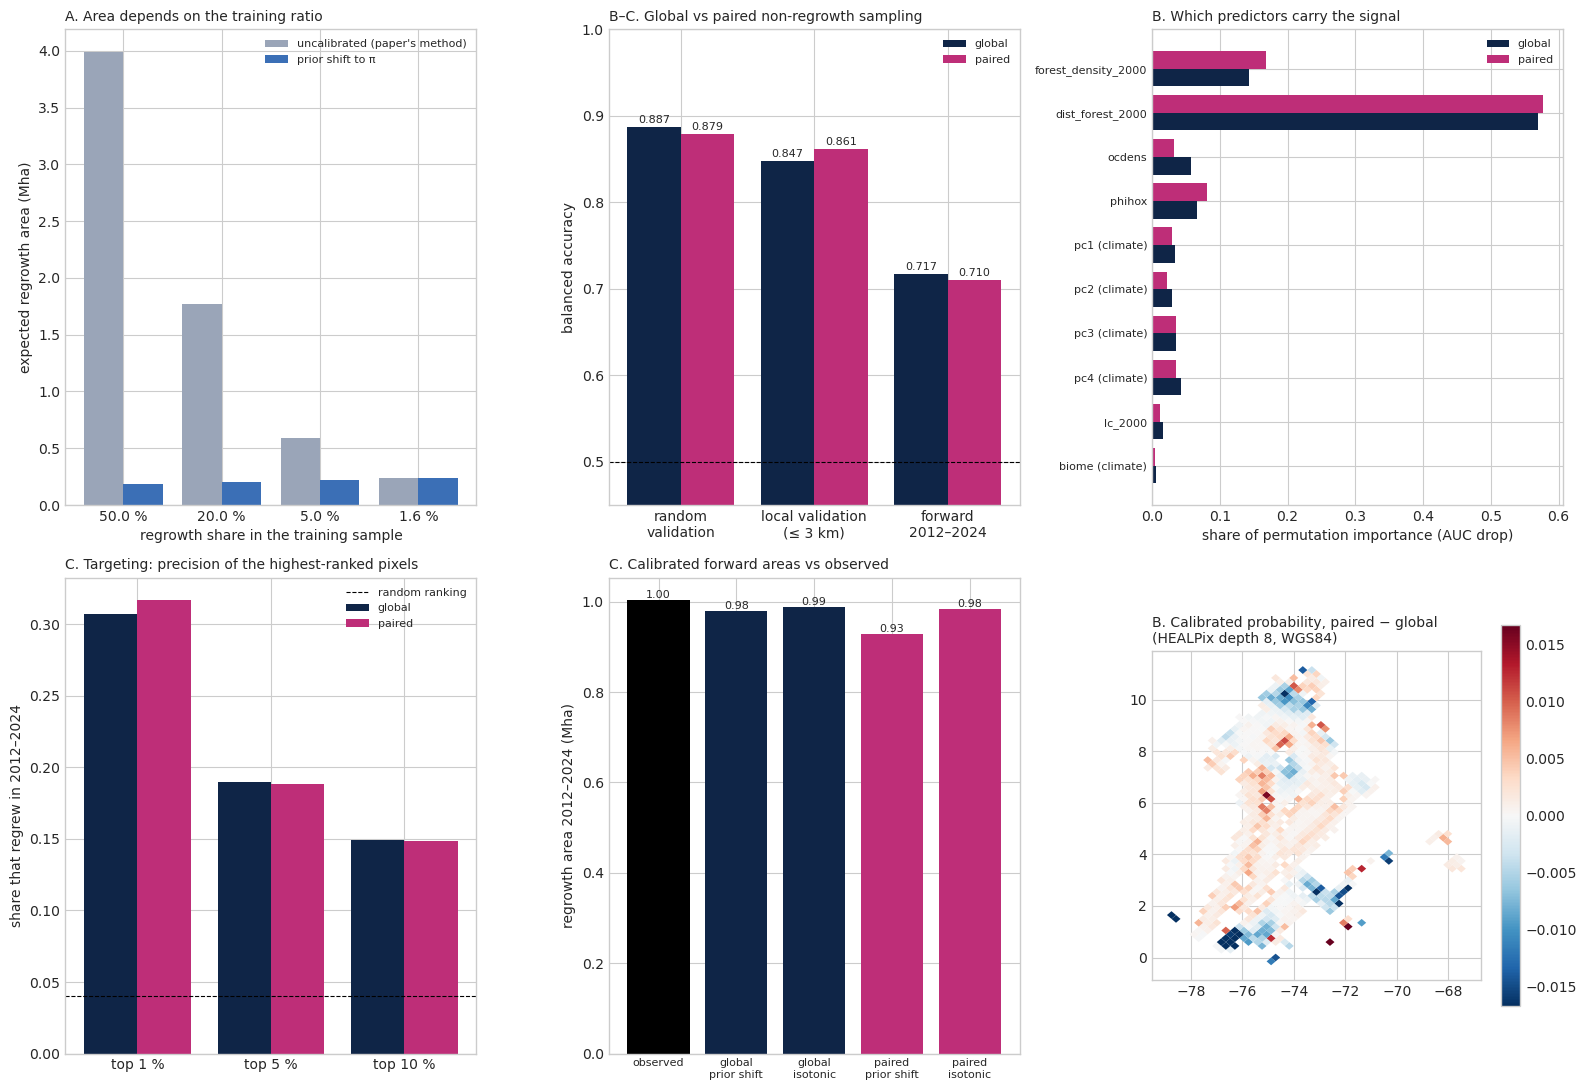

In [8]:
def val_of(part: str, design: str, metric: str) -> float:
    return float(res.loc[(res.part == part) & (res.design == design) & (res.metric == metric), "value"].iloc[0])


def cell_polys(ids: np.ndarray) -> list[np.ndarray]:
    lo, la = vertices(ids.astype("uint64"), HP_DEPTH, ellipsoid="WGS84")
    lo = (np.asarray(lo) + 180) % 360 - 180
    return [np.column_stack([a, b]) for a, b in zip(lo, np.asarray(la))]


fig = plt.figure(figsize=(16, 11))
gsp = fig.add_gridspec(2, 3)
C_GLOBAL, C_PAIRED, C_UNCAL, C_CAL = "#0f2547", "#be2e78", "#9aa5b8", "#3b6fb6"

ax = fig.add_subplot(gsp[0, 0])
designs = [d for d in prev.design.unique()]
labels = [f"{float(d.split('_')[-1]) * 100:.1f} %" for d in designs]
x = np.arange(len(designs))
ax.bar(x - 0.2, [val_of("A_prevalence", d, "expected_area_uncalibrated_mha") for d in designs], 0.4, color=C_UNCAL,
       label="uncalibrated (paper's method)")
ax.bar(x + 0.2, [val_of("A_prevalence", d, "expected_area_prior_shift_mha") for d in designs], 0.4, color=C_CAL,
       label="prior shift to π")
ax.set_xticks(x, labels)
ax.set_xlabel("regrowth share in the training sample")
ax.set_ylabel("expected regrowth area (Mha)")
ax.set_title("A. Area depends on the training ratio", fontsize=10, loc="left")
ax.legend(fontsize=8)

ax = fig.add_subplot(gsp[0, 1])
groups = [("random\nvalidation", "B_paired", "random_validation_balanced_accuracy"),
          ("local validation\n(≤ 3 km)", "B_paired", "local_validation_balanced_accuracy"),
          ("forward\n2012–2024", "C_forward", "forward_balanced_accuracy")]
x = np.arange(len(groups))
for off, design, col in [(-0.2, "global", C_GLOBAL), (0.2, "paired", C_PAIRED)]:
    vals = [val_of(p, design, mt) for _, p, mt in groups]
    ax.bar(x + off, vals, 0.4, color=col, label=design)
    for xx, v in zip(x + off, vals):
        ax.text(xx, v + 0.005, f"{v:.3f}", ha="center", fontsize=8)
ax.axhline(0.5, color="k", lw=0.8, ls="--")
ax.set_xticks(x, [g_[0] for g_ in groups])
ax.set_ylim(0.45, 1)
ax.set_ylabel("balanced accuracy")
ax.set_title("B–C. Global vs paired non-regrowth sampling", fontsize=10, loc="left")
ax.legend(fontsize=8)

ax = fig.add_subplot(gsp[0, 2])
tab = imp.pivot_table(index="variable", columns="design", values="share").loc[FINAL_VARS]
y = np.arange(len(tab))
ax.barh(y + 0.2, tab["global"], 0.4, color=C_GLOBAL, label="global")
ax.barh(y - 0.2, tab["paired"], 0.4, color=C_PAIRED, label="paired")
ax.set_yticks(y, [f"{v} (climate)" if v in CLIMATE_VARS else v for v in tab.index], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("share of permutation importance (AUC drop)")
ax.set_title("B. Which predictors carry the signal", fontsize=10, loc="left")
ax.legend(fontsize=8)

ax = fig.add_subplot(gsp[1, 0])
ks = [1, 5, 10]
x = np.arange(len(ks))
for off, design, col in [(-0.2, "global", C_GLOBAL), (0.2, "paired", C_PAIRED)]:
    ax.bar(x + off, [val_of("C_forward", design, f"forward_precision_top{k}pct") for k in ks], 0.4, color=col,
           label=design)
ax.axhline(val_of("C_forward", "observed", "prevalence_2012_2024"), color="k", lw=0.8, ls="--",
           label="random ranking")
ax.set_xticks(x, [f"top {k} %" for k in ks])
ax.set_ylabel("share that regrew in 2012–2024")
ax.set_title("C. Targeting: precision of the highest-ranked pixels", fontsize=10, loc="left")
ax.legend(fontsize=8)

ax = fig.add_subplot(gsp[1, 1])
items = [("observed", val_of("C_forward", "observed", "observed_regrowth_area_mha"), "k")]
for design, col in [("global", C_GLOBAL), ("paired", C_PAIRED)]:
    items += [(f"{design}\nprior shift", val_of("C_forward", design, "predicted_regrowth_area_prior_shift_pi1_mha"), col),
              (f"{design}\nisotonic", val_of("C_forward", design, "predicted_regrowth_area_isotonic_period1_mha"), col)]
ax.bar(range(len(items)), [i[1] for i in items], color=[i[2] for i in items])
for xx, (_, v, _) in enumerate(items):
    ax.text(xx, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(items)), [i[0] for i in items], fontsize=8)
ax.set_ylabel("regrowth area 2012–2024 (Mha)")
ax.set_title("C. Calibrated forward areas vs observed", fontsize=10, loc="left")

ax = fig.add_subplot(gsp[1, 2])
cells = lonlat_to_healpix(g.lon.to_numpy(), g.lat.to_numpy(), HP_DEPTH, ellipsoid="WGS84")
diff = pd.DataFrame({"cell": cells, "num": (p_cal["paired"] - p_cal["global"]) * g.a.to_numpy(),
                     "den": g.a.to_numpy()}).groupby("cell").sum()
diff = (diff.num / diff.den)[diff.den > 0.1 * diff.den.max()]
lim = float(np.nanquantile(np.abs(diff), 0.98))
pc = PolyCollection(cell_polys(diff.index.to_numpy()), array=diff.to_numpy(), cmap="RdBu_r", edgecolor="none")
pc.set_clim(-lim, lim)
ax.add_collection(pc)
ax.autoscale_view()
ax.set_aspect("equal")
ax.set_title("B. Calibrated probability, paired − global\n(HEALPix depth 8, WGS84)", fontsize=10, loc="left")
fig.colorbar(pc, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(FIGURES / "sampling_design.png", dpi=150, bbox_inches="tight")
plt.show()

## What this shows (Colombia)

- **A — the training ratio sets the area, not the ranking.** From a 50 % to a 1.6 %
  (landscape) regrowth share, the uncalibrated expected area falls from 3.99 to
  0.24 Mha (17 times), while AUC stays at 0.92–0.95. After the prior shift to π all
  four models agree (0.19–0.24 Mha). This confirms Cloud's first point in Colombia:
  the paper's probability × area sums reflect the 50/50 training ratio.
- **B — paired sampling helps a little locally, and climate is not the issue
  here.** Climate predictors carry only 15 % of the permutation importance in the
  global design (13 % paired); distance to forest dominates (57 %). Paired sampling
  raises specificity on non-regrowth within 3 km of regrowth from 0.842 to 0.904
  (balanced accuracy 0.847 → 0.861) at a small cost on random points (0.887 →
  0.879). Calibrated areas are unchanged (0.208 Mha both, isotonic); the plain prior
  shift under-estimates for the paired model (0.155), as Cloud predicts. 74 % of the
  top-5 % pixels are shared; the paired model moves priorities further into moist
  forests (biome 1: 80 % → 88 % of the top 5 %).
- **C — no gain for predicting future regrowth.** Forward balanced accuracy 0.717
  (global) vs 0.710 (paired), AUC 0.799 vs 0.794; precision of the top 1 % 0.307 vs
  0.317 (random ranking 0.040). This is a weak test of pairing: with MapBiomas labels
  82 % of non-regrowth points are already within 3 km of regrowth, so the two
  training samples differ little.

Our model is trained on Colombia only, which already removes most of the pantropical
climate contrast that Cloud identifies in the paper's global sample. The sampling
design therefore matters much less here than in his Brazil analysis of the global
model; the training-ratio effect on areas holds fully.